# Group Project Team 009

## Introduction

**1. Background information** 

PLAICraft is a research data-collection project designed to support the development of advanced embodied AI. Imagine a future where we can speak to an AI inside a virtual world like Minecraft, and it not only understands us but also responds and behaves like a real person. That is the vision behind this project. Embodied AI refers to artificial intelligence that can think, act, and learn within a simulated or real environment—much like humans do. By participating in this study, we contribute to Minecraft gameplay and behavioral data, helping us gather the thousands of hours needed to train and improve such systems.

Our long-term goal is to design new architectures and learning algorithms for embodied AI agents that could eventually function as intelligent NPCs in Minecraft—and potentially in other applications as well. While the data we collect is primarily useful for Minecraft NPC development, the open-world nature of the game allows us to explore many meaningful research questions, such as:

- What goals do players naturally pursue while playing Minecraft?

- What does it truly mean for an agent to be intelligent?

- How can we design agents that learn continually through interaction?

No other project records spoken interactions between players, nor does any existing Minecraft AI research effort fully embrace the complexity and freedom of the open-world Minecraft environment. PLAICraft is unique in both its scope and ambition.

**2. Broad question of the group project**

As one of the contributors to this project, our group chose to solve one of the broad questions: 
Question 1: What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and/or how do these features differ between various player types?

To answer the question above, our group chose the data set "players.csv" to clarify the problem and do the analysis. 

**3. Data Description: players.csv** 

- Variable names: experience, hashedEmail, name, gender, played_hours, Age, subscribe
- Number of variables: 7
- Data type:
  - Character (chr): experience, hashedEmail, name, gender
  - Double (dbl): played_hours, Age
  - Logical (lgl): subscribe
- Type of variable:
  - Numeric: played_hours, Age
  - Categorical: experience, gender, subscribe
- Mean after removing NA observation (displayed in mean_table below in part 3): 
  - played_hours: 5.90 (h)
  - Age: 21.14 (years old)
- Max/min value for numeric variable: 
  - played_hours: max = 223.1 (h), min = 0 (h)
  - Age: max = 58 (years old), min=  9 (years old)
- Number of observations: 196
- Data issue:
  - All variables are not in the same format, so we need to change the names of the variables "Age" and "hashedEmail" to "age" and "hashed_email".
  - The variables "hashedEmail" and "name" are not useful for modeling, so they should be removed to make the data tidy.
  - Categorical variables may not be converted into factors, so we need to convert all these variables to factors to make sure the prediction model can run smoothly.
  - There might be NA values, so we need to check and remove them before modeling.
  - The data might have variables that are more significant, so we nees to standardize and center the numeric data before applying the prediction model.
- Potential issue:
    - There might be feature interaction in the data, which means some features only become meaningful together, not individually.
    - The data might have sampling bias, meaning that the data does not correctly describe the pattern and could lead to wrong results.

## Methods & Results

**1. Cleaning and wrangling data**
  - Remove columns that are not used: hashed_email, name
  - Remove NA values in each column to tidy the data.
  - Convert categorical variables (subscribe, gender, experience) into factors

**2. Exploratory data analysis with visualization**
- Figure 1: Played Hours by Subscription. The histogram shows that the majority of players have low played hours, under 50 hours, and all of the non-subscribers are in this group.  Additionally, the proportion of subscribers in this group is 75%. However, for the minority of players, those who play longer, over 50 hours, subscription rates are significantly higher, nearly 100%.
- Figure 2: Age Distribution by Subscription Status. The bar graph demonstrates that most of the players, subscribers, and non-subscribers are below 30, with subscribers accounting for the highest proportion, while a minority of them are older, with the percentage of unsubscribe significantly rising. The number of non-subscribers in the age range 30-45 has the highest percentage compared to other age range.
- Figure 3: Gender by Subscription Status. The bar graph indicates that all of the genders have higher percentage in subscribers, with the highest proportion in "Male". Additionally, the number of players of "Male" is the highest, followed by "Female" and "Other".

From the exploratory data analysis, we could see that in Figure 1, all non-subscribers played below 50 hours, and in the higher-played-hour groups, all of them are subscribers. This pattern shows that the played hours is not a good predictor, since nearly everyone has low played hours, under 50, making subscribers and non-subscribers look almost the same. Only a few extreme outliers exist, which distort KNN distances. There is also no clear separation for classification in this case. Therefore, played hours is not a good predictor, so we just use "experience", "age", and "gender" as predictors in the analysis.

**3. Methods**
   

In [82]:
install.packages("caret")   
library(caret)
library(tidyverse)
library(tidymodels)
library(repr)
library(kknn)
players <- read_csv("individual/players.csv")

clean_players <- players |> select(c(1,2,4,6,7))|> 
filter(!is.na(Age)) |> 
mutate(subscribe = as.factor(subscribe))|>  
mutate(gender = fct_collapse(
    gender,
    Male = c("Male"),
    Female = c("Female"),
    Other = c("Non-binary", "Other", "Two-Spirited", "Prefer not to say","Agender")))

head(clean_players)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:kknn’:

    contr.dummy


The following objects are masked from ‘package:yardstick’:

    precision, recall, sensitivity, specificity


The following object is masked from ‘package:purrr’:

    lift


Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `gender = fct_collapse(...)`.
Caused by warning:
! Unknown levels in `f`: Other”


experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


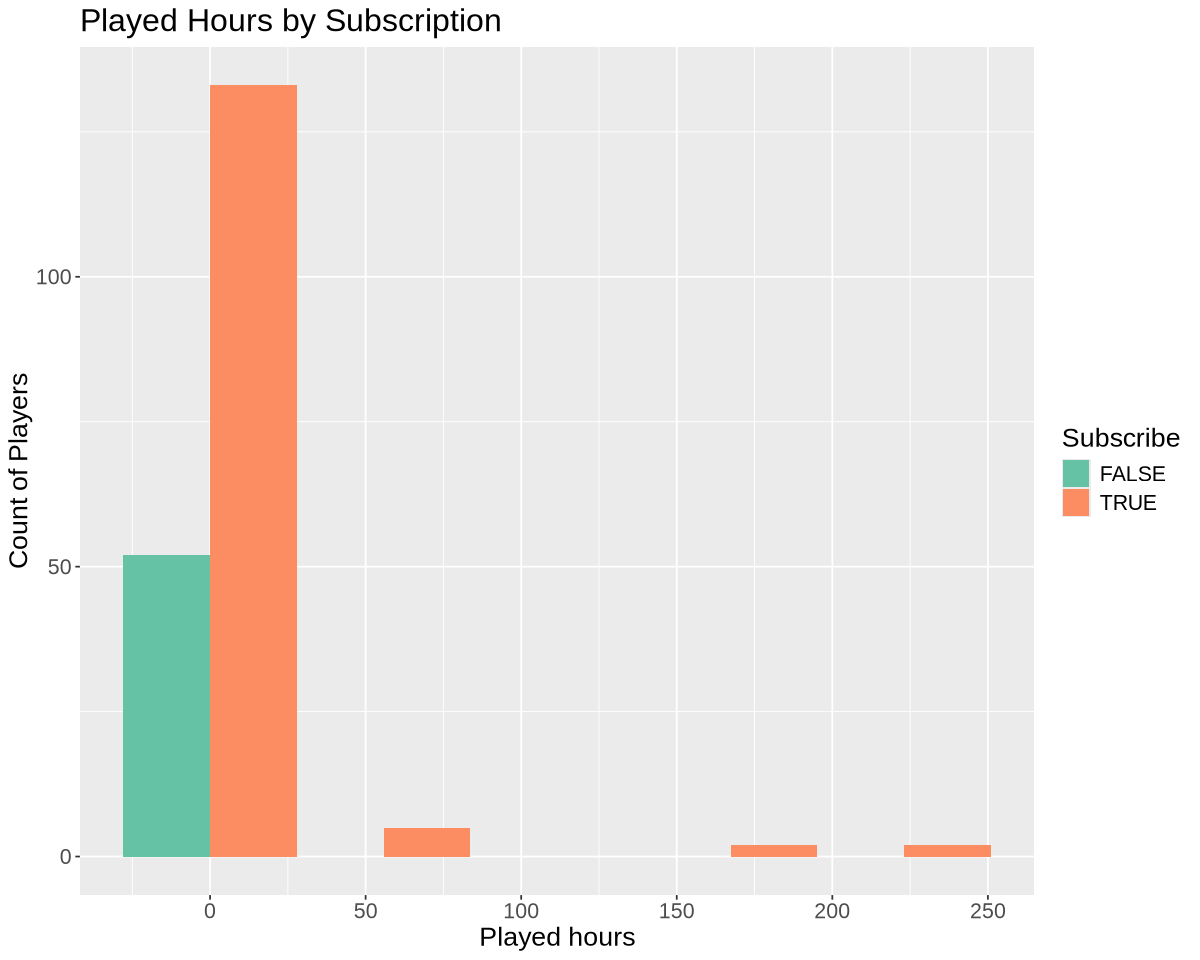

In [15]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = played_hours, fill = subscribe)) +
geom_histogram(position = "dodge", bins=5) +
labs(title = "Played Hours by Subscription",
       x = "Played hours", y = "Count of Players", fill = "Subscribe") +
theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set2')

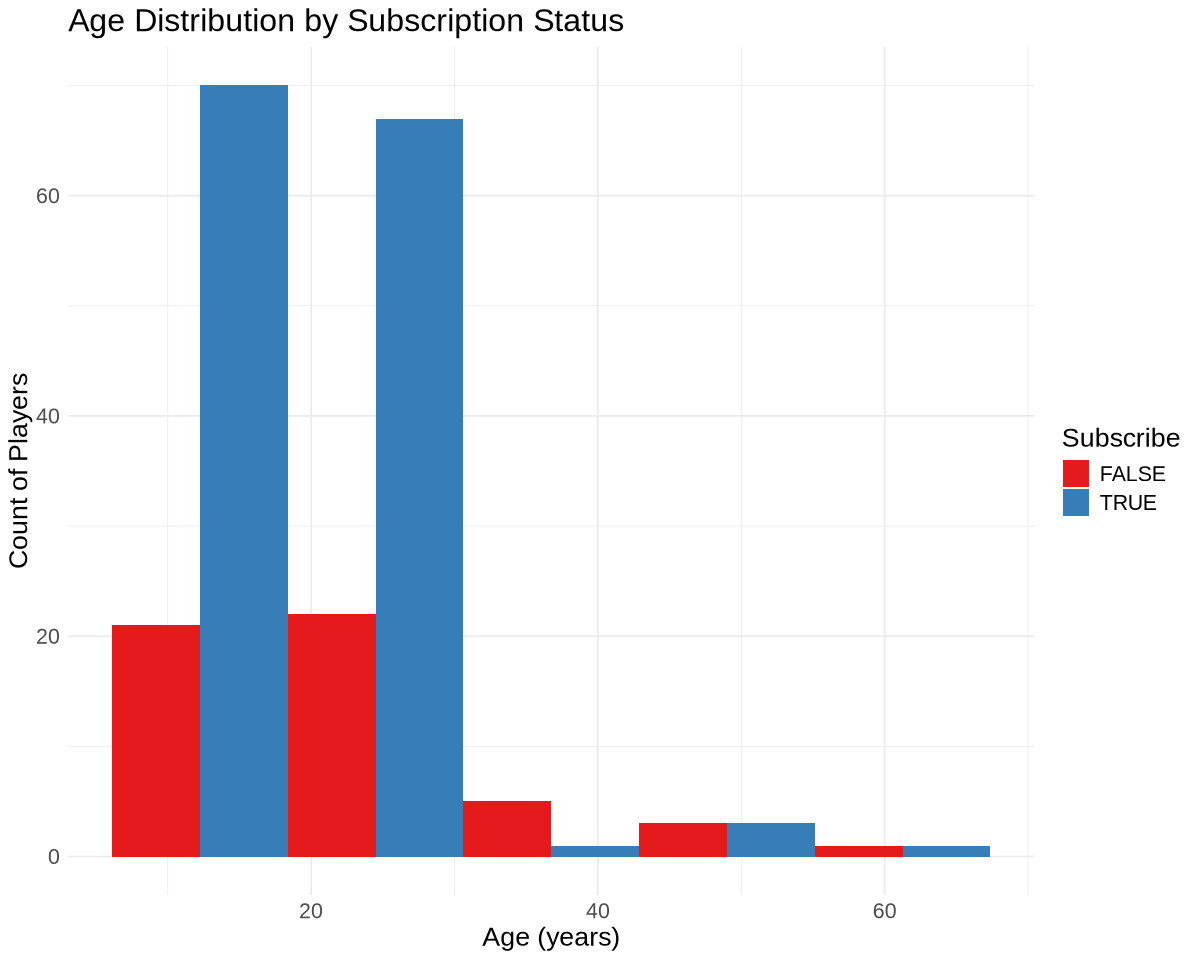

In [22]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = Age, fill = subscribe)) +
  geom_histogram(position = "dodge", bins = 5) +
  labs(title = "Age Distribution by Subscription Status",
       x = "Age (years)", y = "Count of Players", fill = "Subscribe") +
  theme_minimal() +theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set1')

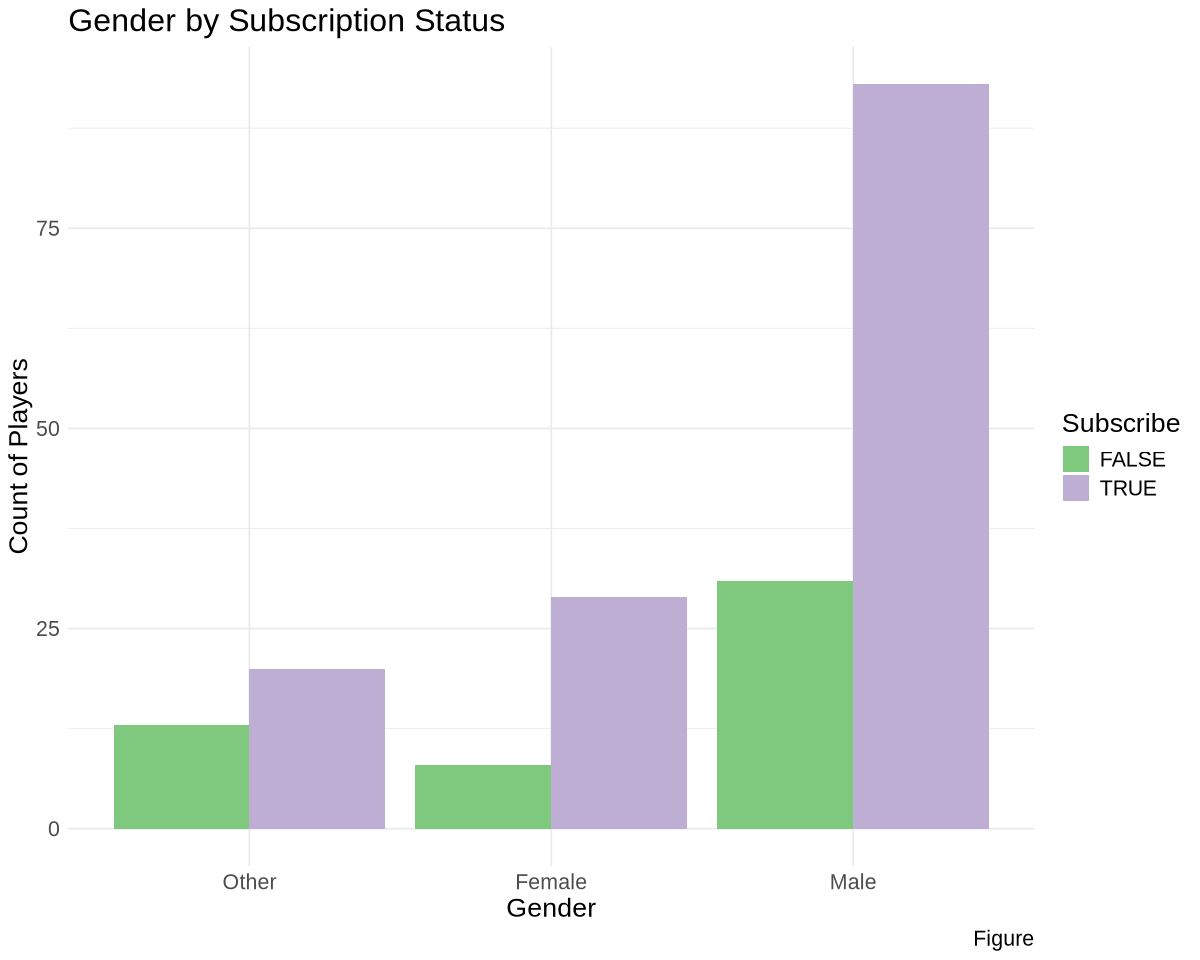

In [51]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = gender, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Gender by Subscription Status",
       x = "Gender", y = "Count of Players", fill = "Subscribe", caption = "Figure") +
  theme_minimal() + theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Accent' ) 

## Gender(one hot encoding)

In [24]:
clean_players_gender <- clean_players|> mutate(gender = as.factor(gender)) #one hot encoding requires it to be in factor form
gender_matrix <- model.matrix(~ gender-1, data = clean_players) # ~gender -1 means I change gender into numeric form
gender_players <- clean_players |>
  bind_cols(as_tibble(gender_matrix)) # change from matrix form to table form
head(gender_players)

experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Pro,TRUE,30.3,Male,9,0,0,1
Veteran,TRUE,3.8,Male,17,0,0,1
Veteran,FALSE,0.0,Male,17,0,0,1
Amateur,TRUE,0.7,Female,21,0,1,0
Regular,TRUE,0.1,Male,21,0,0,1
Amateur,TRUE,0.0,Female,17,0,1,0


In [5]:
set.seed(1123) # set. seed function makes sure you will obtain the exact same sequence of "random" numbers every time you run the code, the number inside is arbitary
# split
gender_split <- initial_split(gender_players, prop = 0.75, strata = subscribe)
gender_train <- training(gender_split)
gender_test <- testing(gender_split)

# recipe
gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [12]:
head(gender_train)

experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Veteran,FALSE,0.0,Male,17,0,0,1
Amateur,FALSE,0.0,Male,22,0,0,1
Amateur,FALSE,0.1,Female,17,0,1,0
Veteran,FALSE,0.0,Male,23,0,0,1
Veteran,FALSE,0.1,Male,18,0,0,1
Amateur,FALSE,0.0,Other,33,1,0,0


In [42]:
# specification
gender_spec_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

# k-values
gender_ks <- tibble(neighbors = 1:20)

# v-fold
gender_vfold <- vfold_cv(gender_train, v = 5, strata = subscribe)

In [25]:
# workflow with validation
gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec_tune) |>
  tune_grid(resamples = gender_vfold, grid = gender_ks) 

# accuracy
gender_tune_accuracy <- gender_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(gender_tune_accuracy)
# rm(list = ls())

neighbors,mean
<int>,<dbl>
17,0.4203777
18,0.4203777
19,0.3996880
20,0.3996880
13,0.3789984
14,0.3789984


In [40]:
gender_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 17) |>
  set_engine("kknn") |>
  set_mode("classification")

gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [41]:
# workflow with validation
gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec) |>
  fit(data = gender_train)

In [39]:
gender_test_predictions <- predict(gender_fit, gender_test) |>
  bind_cols(gender_test)

In [94]:
head(gender_test_predictions)

.pred_class,experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<fct>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,Veteran,TRUE,3.8,Male,17,0,0,1
FALSE,Regular,TRUE,0.1,Male,21,0,0,1
FALSE,Amateur,FALSE,0.0,Male,21,0,0,1
FALSE,Amateur,TRUE,0.1,Male,47,0,0,1
FALSE,Veteran,TRUE,0.0,Other,17,1,0,0
TRUE,Amateur,TRUE,48.4,Female,17,0,1,0


In [95]:
gender_test_predictions |>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.3265306


In [98]:
confusion_matrix_result <- confusion_matrix_result <- confusionMatrix(
  data      = gender_test_predictions$.pred_class,   
  reference = gender_test_predictions$subscribe,     
  positive  = "TRUE")
confusion_matrix_result

Confusion Matrix and Statistics

          Reference
Prediction FALSE TRUE
     FALSE    11   31
     TRUE      2    5
                                          
               Accuracy : 0.3265          
                 95% CI : (0.1995, 0.4754)
    No Information Rate : 0.7347          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : -0.0087         
                                          
 Mcnemar's Test P-Value : 1.093e-06       
                                          
            Sensitivity : 0.1389          
            Specificity : 0.8462          
         Pos Pred Value : 0.7143          
         Neg Pred Value : 0.2619          
             Prevalence : 0.7347          
         Detection Rate : 0.1020          
   Detection Prevalence : 0.1429          
      Balanced Accuracy : 0.4925          
                                          
       'Positive' Class : TRUE            
                     

## Age (ordinal encoding)

In [170]:
head(clean_players)

experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


In [150]:
set.seed(1123)
# split，非必须
age_split <- initial_split(clean_players, prop = 0.75, strata = subscribe) 
age_train <- training(players_split)
age_test <- testing(players_split)

In [172]:
# recipe
age_recipe <- recipe(subscribe ~ Age, data = age_train) |>
  step_dummy(all_nominal(), -all_outcomes()) |>  # Convert categorical variables to dummy variables, ensure that it's all numeric before scaling
  step_scale(all_numeric(), -all_outcomes())

In [185]:
# specification
age_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

# k-values
age_ks <- tibble(neighbors = 1:20)

In [186]:
# v-fold
age_vfold <- vfold_cv(age_train, v = 5, strata = subscribe)

In [190]:
# workflow with validation
age_tune_fit <- workflow() |>
  add_recipe(age_recipe) |>
  add_model(age_tune) |>
  tune_grid(resamples = age_vfold, grid = players_ks) 

In [191]:
# accuracy
age_tune_accuracy <- age_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(age_tune_accuracy)

neighbors,mean
<int>,<dbl>
19,0.6007882
20,0.5869951
18,0.5369951
17,0.5232020
3,0.4889491
4,0.4889491


In [192]:
age_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 8) |>
  set_engine("kknn") |>
  set_mode("classification")

In [193]:
age_vfold <- vfold_cv(age_train, v = 5, strata = subscribe)

In [194]:
age_fit <- workflow() |>
  add_recipe(age_recipe) |>
  add_model(age_spec) |>
  fit(data = age_train)

age_test_predictions <- predict(age_fit, age_test) |>
  bind_cols(age_test)
head(age_test_pred)

.pred_class,experience,subscribe,played_hours,gender,Age,experience_numeric
<fct>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
TRUE,Veteran,TRUE,3.8,Male,17,4
TRUE,Regular,TRUE,0.1,Male,21,3
TRUE,Amateur,FALSE,0.0,Male,21,2
FALSE,Amateur,TRUE,0.1,Male,47,2
TRUE,Veteran,TRUE,0.0,Other,17,4
TRUE,Amateur,TRUE,48.4,Female,17,2


In [195]:
age_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.5510204


In [196]:
confusion_matrix_result <- confusion_matrix_result <- confusionMatrix(
  data      = age_test_predictions$.pred_class,   
  reference = age_test_predictions$subscribe,     
  positive  = "TRUE")
confusion_matrix_result

Confusion Matrix and Statistics

          Reference
Prediction FALSE TRUE
     FALSE     8   17
     TRUE      5   19
                                          
               Accuracy : 0.551           
                 95% CI : (0.4023, 0.6933)
    No Information Rate : 0.7347          
    P-Value [Acc > NIR] : 0.99828         
                                          
                  Kappa : 0.1106          
                                          
 Mcnemar's Test P-Value : 0.01902         
                                          
            Sensitivity : 0.5278          
            Specificity : 0.6154          
         Pos Pred Value : 0.7917          
         Neg Pred Value : 0.3200          
             Prevalence : 0.7347          
         Detection Rate : 0.3878          
   Detection Prevalence : 0.4898          
      Balanced Accuracy : 0.5716          
                                          
       'Positive' Class : TRUE            
                     

## Experience (ordinal encoding)

In [197]:
experience_encoded = factor(clean_players$experience,
  levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"),
  ordered = TRUE)
experience_numeric = as.numeric(experience_encoded)

In [198]:
clean_experience_players <- clean_players |> mutate( experience_numeric = experience_numeric)
head(clean_experience_players)

experience,subscribe,played_hours,gender,Age,experience_numeric
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
Pro,TRUE,30.3,Male,9,5
Veteran,TRUE,3.8,Male,17,4
Veteran,FALSE,0.0,Male,17,4
Amateur,TRUE,0.7,Female,21,2
Regular,TRUE,0.1,Male,21,3
Amateur,TRUE,0.0,Female,17,2


In [199]:
experience_split <- initial_split(clean_experience_players, prop = 0.75, strata = subscribe)
experience_train <- training(experience_split)
experience_test <- testing(experience_split)

experience_recipe <- recipe(subscribe ~ experience_numeric, data = clean_experience_players) |>
step_dummy(all_nominal(), -all_outcomes()) |>  
  step_scale(all_numeric(), -all_outcomes())

experience_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

experience_ks <- tibble(neighbors = 1:20)

In [201]:
experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

# workflow with validation
experience_tune_fit <- workflow() |>
  add_recipe(experience_recipe) |>
  add_model(experience_tune) |>
  tune_grid(resamples = experience_vfold, grid = experience_ks) 
 
# accuracy
experience_tune_accuracy <- experience_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(experience_tune_accuracy)

neighbors,mean
<int>,<dbl>
19,0.5517734
20,0.5517734
17,0.5165681
18,0.4958621
16,0.4699015
15,0.4627586


In [202]:
experience_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 19) |>
  set_engine("kknn") |>
  set_mode("classification")

In [203]:
experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

In [204]:
experience_fit <- workflow() |>
  add_recipe(experience_recipe) |>
  add_model(experience_spec) |>
  fit(data = age_train)

In [206]:
experience_test_predictions <- predict(experience_fit, experience_test) |>
  bind_cols(experience_test)
head(experience_test_predictions)

.pred_class,experience,subscribe,played_hours,gender,Age,experience_numeric
<fct>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
TRUE,Regular,TRUE,0.1,Male,21,3
TRUE,Regular,TRUE,0.0,Female,19,3
FALSE,Amateur,FALSE,0.0,Male,21,2
FALSE,Amateur,FALSE,0.0,Male,22,2
TRUE,Beginner,TRUE,0.0,Male,17,1
FALSE,Amateur,TRUE,0.7,Female,21,2


In [207]:
experience_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.5918367


In [208]:
confusion_matrix_result <- confusion_matrix_result <- confusionMatrix(
  data      = experience_test_predictions$.pred_class,   
  reference = experience_test_predictions$subscribe,     
  positive  = "TRUE")
confusion_matrix_result

Confusion Matrix and Statistics

          Reference
Prediction FALSE TRUE
     FALSE     8   15
     TRUE      5   21
                                        
               Accuracy : 0.5918        
                 95% CI : (0.4421, 0.73)
    No Information Rate : 0.7347        
    P-Value [Acc > NIR] : 0.99024       
                                        
                  Kappa : 0.1595        
                                        
 Mcnemar's Test P-Value : 0.04417       
                                        
            Sensitivity : 0.5833        
            Specificity : 0.6154        
         Pos Pred Value : 0.8077        
         Neg Pred Value : 0.3478        
             Prevalence : 0.7347        
         Detection Rate : 0.4286        
   Detection Prevalence : 0.5306        
      Balanced Accuracy : 0.5994        
                                        
       'Positive' Class : TRUE          
                                        

## Discussion

summarize what you found(accuracy)
discuss whether this is what you expected to find
discuss what impact could such findings have
discuss what future questions could this lead to

## Reference 